# Work flow
## Generate spike trains
## Generate calcium dynamic from spike trains with multiple parameters
## Perform spike deconvolution and compare the result with original spike trains

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from oasis.functions import gen_data, gen_sinusoidal_data, deconvolve, estimate_parameters
from oasis.plotting import simpleaxis
from oasis.oasis_methods import oasisAR1, oasisAR2

/home/ysaito/.conda/envs/suite2p-2/lib/python3.9/site-packages/oasis/functions.py:13: UserWarning: Could not find cvxpy. Don't worry, you can still use OASIS, just not the slower interior point methods we compared to in the papers.
  warn("Could not find cvxpy. Don't worry, you can still use OASIS, " +


In [13]:
def generate_spikes(rate, duration, sf_ephys):
    """
    Generate spikes based on a Poisson process.
    
    Parameters:
    - rate: average rate of spikes per second.
    - duration: duration of the spike train in seconds.
    - sf_ephys: sampling frequency of spiking activity
    
    Returns:
    - spike_times: array of spike times.
    """
    mean_interval = 1.0 / rate
    times = np.random.exponential(scale=mean_interval, size=int(rate * duration * 1.5))
    spike_times = np.cumsum(times)
    spike_times = spike_times[spike_times < duration]
    spike_times = (spike_times*sf_ephys).astype('int')
    t_ephys=np.arange(0, duration, 1/sf_ephys)
    return t_ephys,spike_times

In [14]:
def simulate_calcium_dynamics(spike_times, duration, sf_imaging=15.6, tau=1.0, A=0.5, Ca_rest=0.1, sigma=0.1, eta=0.01):
    """
    Simulate calcium dynamics with noise based on spike times.
    
    Parameters:
    - spike_times: array of spike times.
    - duration: duration of the simulation in seconds.
    - dt: time step of the simulation in seconds.
    - tau: decay constant of the calcium signal.
    - sf_imaging: sampling frequency of calcium signal
    - A: amplitude of calcium increase per spike.
    - Ca_rest: resting calcium concentration.
    - sigma: standard deviation of the measurement noise.
    - eta: scale of the evolution noise.
    
    Returns:
    - t: array of time points.
    - Ca: array of noisy calcium concentrations over time.
    """
    dt=1/sf_imaging
    t_imaging = np.arange(0, duration, dt)
    Ca = np.zeros_like(t_imaging) + Ca_rest
    B = np.zeros_like(t_imaging)  # Drifting baseline B(t)

    # Simulate the spikes and calcium concentration
    for spike_time in spike_times:
        spike_idx = int(spike_time / dt)
        Ca[spike_idx:] += A * np.exp(-(t_imaging[spike_idx:] - t_imaging[spike_idx]) / tau)

    # Add evolution noise using Brownian motion
    dW = np.random.normal(0, np.sqrt(dt) * eta, size=len(t_imaging))
    B += np.cumsum(dW)  # Integrate the Brownian motion over time

    # Add measurement noise
    measurement_noise = np.random.normal(0, sigma, size=len(t_imaging))

    # Combine the calcium signal with noise
    Ca_noisy = Ca + B + measurement_noise
    return t_imaging, Ca_noisy

In [15]:
def calc_dF_F(F, sf_imaging, win_baseline=60):
    from scipy.ndimage import percentile_filter
    #calculate baseline
    Fbase = percentile_filter(F, percentile=8, size=int(win_baseline*sf_imaging), axes=1)
    #calculate dF/F
    dF_F = (F-Fbase)/Fbase
    return dF_F

In [41]:
np.random.seed(0)
N_Neuron = 100
duration=1000
sf_ephys=10000
sf_imaging=7.65
Spike_train = np.zeros([N_Neuron,int(duration*sf_ephys)])
Ca_dynamics = np.zeros([N_Neuron,int(duration*sf_imaging)])
for i in range(N_Neuron):
    rate=np.random.uniform(0.01, 0.1)
    t_ephys, spike_times=generate_spikes(rate=rate, duration=duration, sf_ephys=sf_ephys)
    Spike_train[i,spike_times]=1
    t_imaging, Ca_dynamics[i] = simulate_calcium_dynamics(spike_times/sf_ephys, duration=duration, sf_imaging=sf_imaging, 
                                              tau=10, A=1, Ca_rest=1, sigma=0.1, eta=0.01)

In [42]:
dF_F=calc_dF_F(Ca_dynamics, sf_imaging, win_baseline=60)

In [43]:
# plt.imshow(Ca_dynamics, aspect=duration/N_Neuron*10, vmin=0,vmax=1, cmap='gray_r')

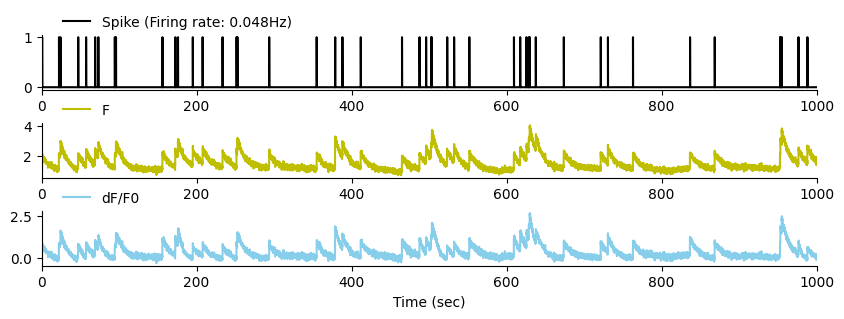

In [44]:
Neuron_ID=1
plt.figure(figsize=(10,3))
plt.subplot(311)
plt.plot(t_ephys,Spike_train[Neuron_ID], color='black', label='Spike (Firing rate: '+str(np.sum(Spike_train[Neuron_ID])/duration)+'Hz)')
plt.xlim(0,duration)
plt.legend(ncol=3, frameon=False, loc=(.02,1));
plt.subplot(312)
plt.plot(t_imaging,Ca_dynamics[Neuron_ID], color='y', label='F')
plt.xlim(0,duration)
plt.legend(ncol=3, frameon=False, loc=(.02,1));
plt.subplot(313)
plt.plot(t_imaging,dF_F[Neuron_ID], color='skyblue', label='dF/F0')
plt.xlim(0,duration)
plt.legend(ncol=3, frameon=False, loc=(.02,1));
plt.xlabel('Time (sec)')
sns.despine()

plt.subplots_adjust(wspace=0.4, hspace=0.6)

In [45]:
# noise_level = np.median(abs(np.diff(dF_F,axis=1)*100)/np.sqrt(sf_imaging),axis=1)
# plt.figure(figsize=(3,2))
# plt.hist(noise_level, bins=20);

In [46]:
from oasis.functions import gen_data, gen_sinusoidal_data, deconvolve, estimate_parameters
from oasis.plotting import simpleaxis
from oasis.oasis_methods import oasisAR1, oasisAR2

In [47]:
def plot_trace(t_imaging, t_ephys, dF_F, c, s, true_s, xwindow=[0, 1000]):
    plt.figure(figsize=(10,4), tight_layout=True)
    plt.subplot(311)
    plt.plot(t_imaging, dF_F, label='data', zorder=-12, c='y')
    plt.legend(ncol=3, frameon=False, loc=(.02,.9))
    plt.xlim(xwindow[0], xwindow[1])
    plt.ylim(-0.5,5)
    simpleaxis(plt.gca())
    
    plt.subplot(312)
    plt.plot(t_imaging, c, lw=1, label='denoised')
    plt.plot(t_imaging, dF_F, label='data', zorder=-12, c='y')
    plt.legend(ncol=3, frameon=False, loc=(.02,.9))
    plt.xlim(xwindow[0], xwindow[1])
    plt.ylim(-0.5,5)
    simpleaxis(plt.gca())
    
    plt.subplot(313)
    plt.plot(t_imaging, s, lw=1, label='deconvolved', c='g')
    plt.plot(t_ephys, true_s-1.5, lw=1, label='true spike', c='black')
    plt.ylim(-1,1.5)
    plt.legend(ncol=3, frameon=False, loc=(.02,.9));
    simpleaxis(plt.gca())
    plt.xlim(xwindow[0], xwindow[1])
    plt.xlabel('Time (sec)')
    
    plt.subplots_adjust(wspace=0.4, hspace=0.6)

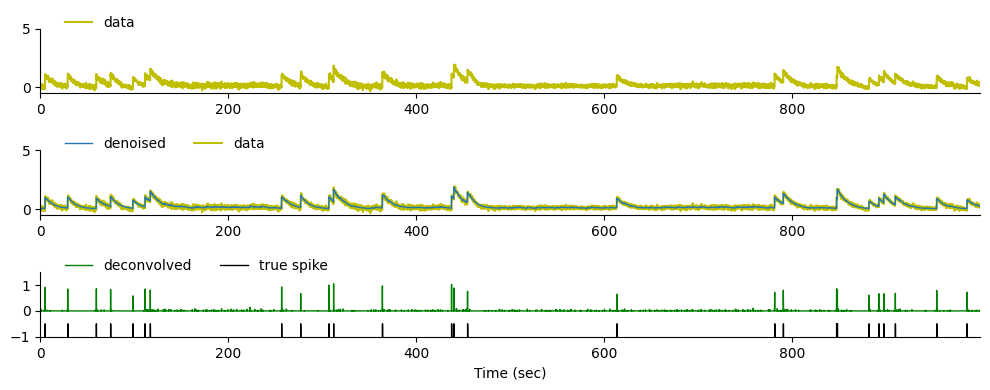

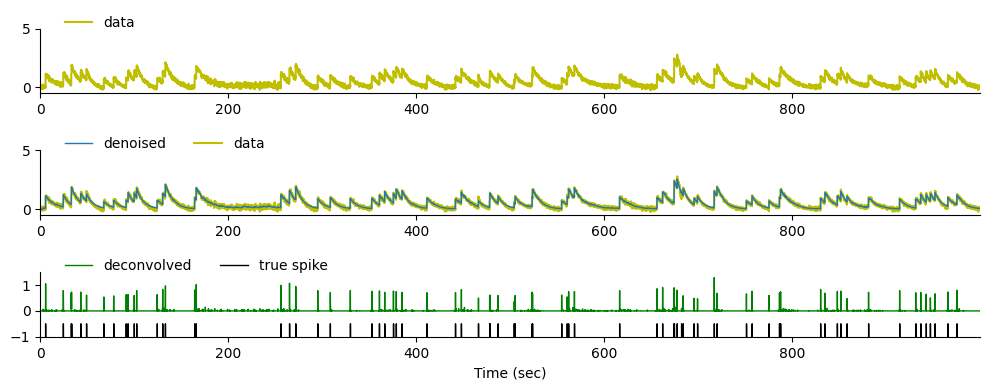

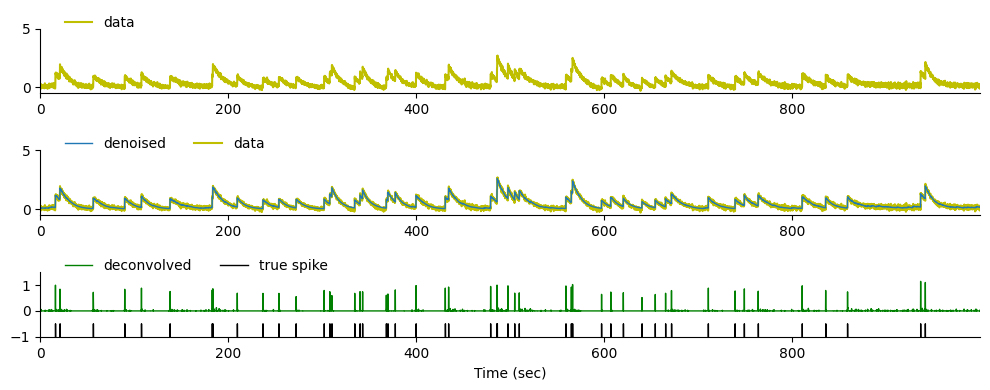

In [48]:
# cellID = np.random.choice(np.arange(0,dF_F.shape[0]), size=3, replace=False)
for i in cellID:
    c, s = oasisAR1(dF_F[i].astype('double'), g=estimate_parameters(dF_F[i], p=1)[0]) 
    plot_trace(t_imaging, t_ephys, dF_F[i], c, s, Spike_train[i],xwindow=[t_imaging.min(), t_imaging.max()])

In [49]:
median_dF_F = np.median(dF_F,axis=1)
corrected_dF_F = dF_F-median_dF_F.reshape(-1,1)

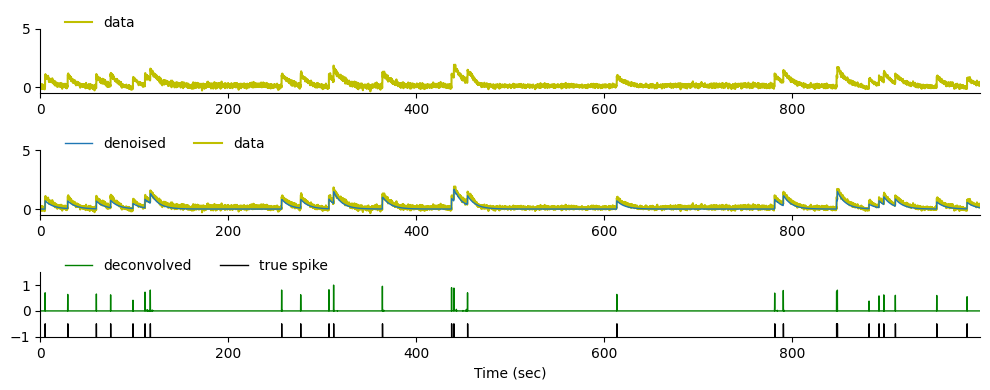

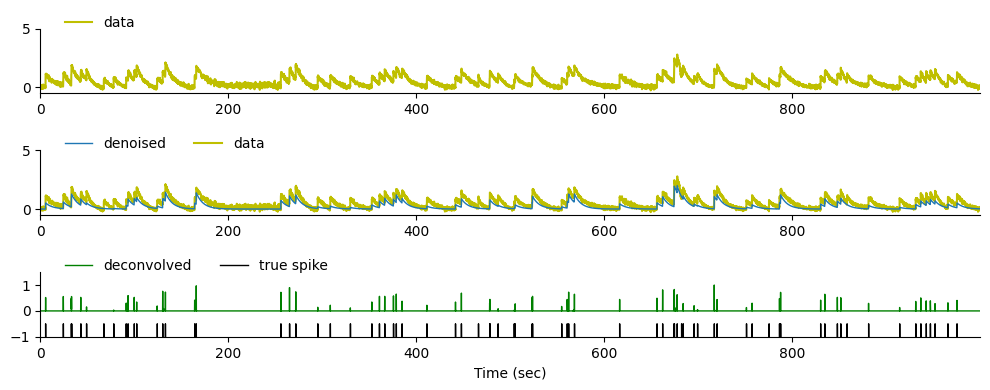

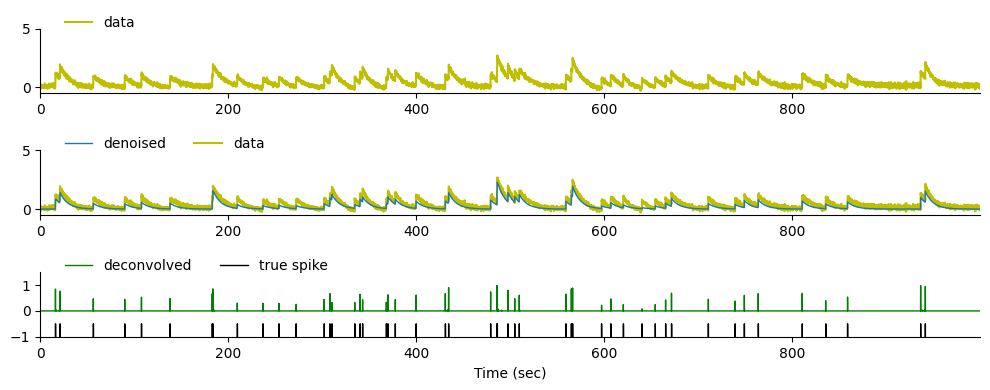

In [50]:
# cellID = np.random.choice(np.arange(0,dF_F.shape[0]), size=3, replace=False)
for i in cellID:
    c, s = oasisAR1(corrected_dF_F[i].astype('double'), g=estimate_parameters(dF_F[i], p=1)[0]) 
    plot_trace(t_imaging, t_ephys, dF_F[i], c, s, Spike_train[i],xwindow=[t_imaging.min(), t_imaging.max()])